In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42 
import matplotlib.pyplot as plt

names = ["chr", "start", "end", "name", "pwm", "strand", "pchr", "pstart", "pend", "tobias", "atac_counts", "atac_profile", "dnase_counts", "dnase_profile", "chip", "atac_obs", "dnase_obs"]

cl="HEPG2"
#pp="pattern_0_CTCF"
chipenc="ENCSR607XFI"
sdict = {"ENCSR607XFI": "pattern_0_CTCF", 
        "ENCSR469FBY": "pattern_1_HNF4A",
        "ENCSR000BNI":"pattern_2_FOXA2"}

In [2]:
import scipy.stats
import seaborn as sns

def make_plot(xkey, keyd, data, color, savef, ax):
    sns.kdeplot(
        ax=ax,
        data=data,
        x=xkey,
        y=keyd,
        levels=5,
        fill=False,
        alpha=0.2,
        color="grey",
        cut=2,

    )

    sns.scatterplot(ax=ax, data=data, x=xkey, y=keyd, s=2, color = color, rasterized=True)
    
    sns.regplot(ax=ax, x=xkey, y=keyd, data=data, scatter=False, ci=None)
    ppr = scipy.stats.pearsonr(data[keyd], data[xkey])
    print(ppr)
    print(scipy.stats.pearsonr(data[keyd], data[xkey]))
    ax.set_title("Pearsonr: " + str(np.round(ppr[0],2)) + " pval: "+str(ppr[1]))
    ax.spines[['right', 'top']].set_visible(False)



/oak/stanford/groups/akundaje/vir/tfatlas/processed_data/ENCSR607XFI/ENCSR607XFI_plus.bigWig
(0.5441268969990046, 0.0)
(0.5441268969990046, 0.0)
(0.9143176008842996, 0.0)
(0.9143176008842996, 0.0)
/oak/stanford/groups/akundaje/vir/tfatlas/processed_data/ENCSR469FBY/ENCSR469FBY_plus.bigWig
(0.47350309086583364, 0.0)
(0.47350309086583364, 0.0)
(0.8203661014149343, 0.0)
(0.8203661014149343, 0.0)
/oak/stanford/groups/akundaje/vir/tfatlas/processed_data/ENCSR000BNI/ENCSR000BNI_plus.bigWig
(0.5670056343996023, 0.0)
(0.5670056343996023, 0.0)
(0.7517278423630863, 0.0)
(0.7517278423630863, 0.0)


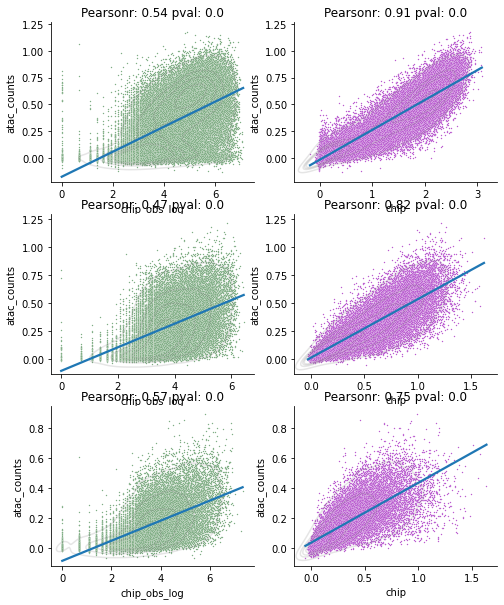

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(8, 10))

my_pal = {"ATAC Observed log counts": "#5FB4EF", "DNase Observed log counts": "#249AEC", "TOBIAS score": "#ABABAB",
         "ChromBPNet ATAC counts contrib": "#7EAD84", "ChromBPNet ATAC profile contrib":"#3D963D",
         "ChromBPNet DNase counts contrib": "#B95BD0", "ChromBPNet DNase profile contrib":"#9B4CAF"}

j=0
for chipenc in ["ENCSR607XFI", "ENCSR469FBY", "ENCSR000BNI" ]:
    bed=chipenc+".bed"
    pp = sdict[chipenc]
    main_dir="/mnt/lab_data2/anusri/chrombpnet/src/evaluation/figure_notebooks/figure_5/chip_seq_compare/new_output_oct_25/"
    data = pd.read_csv(main_dir+cl+"/"+pp+"/"+bed, sep='\t', names=names)

    data.shape
    data.head()

    import pyBigWig as pw

    chip_plus="/oak/stanford/groups/akundaje/vir/tfatlas/processed_data/"+chipenc+"/"+chipenc+"_plus.bigWig"
    chip_minus="/oak/stanford/groups/akundaje/vir/tfatlas/processed_data/"+chipenc+"/"+chipenc+"_minus.bigWig"
    print(chip_plus)
    bw_cp = pw.open(chip_plus)
    bw_cm = pw.open(chip_minus)

    values = []
    for i,r in data.iterrows():
        mid=int((r[1]+r[2])/2)
        val1 = np.sum(np.nan_to_num(bw_cp.values(r[0],mid-50,mid+50)))
        val2 = np.sum(np.nan_to_num(bw_cm.values(r[0],mid-50,mid+50)))
        values.append(val1+val2)
    
    data['chip_counts'] = values
    
    data["chip_obs_log"] = np.log(data["chip_counts"]+1)
    make_plot("chip_obs_log", "atac_counts", data, my_pal["ChromBPNet ATAC counts contrib"], "pearsonr_ctcf_counts.pdf", axes[j,0])
    make_plot("chip", "atac_counts", data, "#B95BD0", "pearsonr_ctcf_counts.pdf", axes[j,1])

    j+=1


plt.savefig("figures/chip-to-atac.pdf", transparent=True, dpi=300)


In [ ]:

#plt.scatter(data['chip_counts'], data['atac_counts'])